# Phase 3 — Full Bayesian concentration analysis with TNIC peer-smoothed priors

This notebook runs the **full Bayesian segment-allocation pipeline of
`05_wrds_analysis.ipynb`** — posterior CR4 / HHI distributions, benchmark
comparison, and aggregate concentration trends — on the **all-firms** WRDS
sample (~2,200 Compustat firms with US business segments), with the prior
augmented by a **TNIC peer-weighted smoothing channel**.

## Design summary

| Choice | Value | Why |
|---|---|---|
| Industry unit | 3-digit NAICS | Matches `05_wrds_analysis.ipynb`; allows apples-to-apples comparison. The 7-bucket custom taxonomy was retail-specific. |
| TNIC mechanism | Peer-weighted smoothing | $\text{tnic\_share}[f,y,k]=\sum_j \text{sim}(f,j,y)\cdot \text{bench\_share}[j,y,k]/\sum_j \text{sim}(f,j,y)$. No anchor list — data-driven, scales to thousands of firms. |
| Prior combination | Additive | $\alpha_{f,s,k,y} = m^{\text{preCOVID}}_{f,s,k} + c_{\text{tnic}}\cdot M_{f,s}\cdot \text{tnic\_share}[f,y,k]$ where $M_{f,s}=\sum_k m^{\text{preCOVID}}_{f,s,k}$. |
| $c_{\text{tnic}}$ | 1.0 | TNIC contributes mass on the same scale as total pre-COVID mass; doesn't dominate, doesn't disappear. We run sensitivity tests as well. |
| Pre-COVID window | 2017–2021 | Matches `05_wrds_analysis.ipynb`. |
| Years > 2023 | TNIC carry-forward from 2023 | TNIC product markets are slow-moving; better than dropping the signal. |
| Firms with no TNIC peers | Uniform 1/K fallback |  |

## Missing-data alerts (verified before this notebook runs)

1. **TNIC ends in 2023** — no native TNIC signal for 2024–2026. Carry-forward applied.
2. **~470 firms in WRDS-seg FY2022 have no TNIC peers** — uniform fallback applied; firms are flagged in §2.
3. **gvkey-padding mismatch** across WRDS files — `wrds_naics_count_by_firmxyear` and `wrds_sales_by_firmxyear` use unpadded gvkeys, while WRDS-seg and TNIC use 6-digit padded. All gvkeys are normalised to 6-digit padded strings in §1.
4. **Keyword channel dropped** — the 19-firm keyword-enriched prior in `priors_draft.csv` from the previous run is *not* overwritten by this notebook; it is a separate artefact for the focal-firms story.

## Output artefacts

- `data/external/priors_all_firms.csv` — one row per (gvkey, year, naics_code) with `alpha_prior`, `alpha_tnic`, `alpha_total`, `prior_mean`.
- `data/processed/posterior_cr4_distribution.csv` and `posterior_hhi_distribution.csv` — draws per (year, naics_code).
- `data/processed/posterior_summary_industry.csv` — posterior quantiles vs benchmark per (year, naics_code).
- `data/processed/priors_c_tnic_sensitivity_means.csv` and `priors_c_tnic_sensitivity_aggregate.csv` — posterior means across a `c_tnic` grid (§10).
- Figures saved to `output/figures/priors_all_firms/` (including `c_tnic_sensitivity_*.png` from §10).


In [5]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

def _find_repo_root(start: Path) -> Path:
    """Walk up looking for a directory that contains data/processed/."""
    for p in [start, *start.parents]:
        if (p / "data" / "processed").is_dir():
            return p
    return start

ROOT = _find_repo_root(Path.cwd())
EXTERNAL = ROOT / "data" / "external"
PROCESSED = ROOT / "data" / "processed"
RAW = ROOT / "data" / "raw"
WRDS_PROC = PROCESSED / "wrds"
OUT_FIGS = ROOT / "output" / "figures" / "priors_all_firms"
OUT_FIGS.mkdir(parents=True, exist_ok=True)

# ---------- Tuning parameters -------------------
PRE_COVID_YEARS = [2017, 2018, 2019, 2020, 2021]
POST_YEARS = [2022, 2023, 2024, 2025]  # 2026 excluded (partial WRDS coverage)
TNIC_END_YEAR = 2023  # TNIC carry-forward beyond this year
C_TNIC = 1.0           # weight of TNIC mass relative to total pre-COVID mass
SUM_THRESHOLD = 0.05   # min sum-of-cosine before TNIC is treated as informative
N_DRAWS = 500          # Dirichlet posterior draws per segment-year
SMOOTH = 1e-9          # Laplace smoother on prior mass
SEED = 20260514

rng = np.random.default_rng(SEED)
np.random.seed(SEED)

print(f"Root: {ROOT}")
print(f"Pre-COVID years for prior: {PRE_COVID_YEARS}")
print(f"Post-period years (posterior inference): {POST_YEARS}")
print(f"TNIC carry-forward applies for years > {TNIC_END_YEAR}")
print(f"c_tnic = {C_TNIC}, n_draws = {N_DRAWS}")


Root: /Users/jgint/Documents/courses/sp26/adsp32104_bayesian/bayes_market_external
Pre-COVID years for prior: [2017, 2018, 2019, 2020, 2021]
Post-period years (posterior inference): [2022, 2023, 2024, 2025]
TNIC carry-forward applies for years > 2023
c_tnic = 1.0, n_draws = 500


## 1. Load WRDS segment-level data and build the NAICS-3 panel

This mirrors the data-prep portion of `05_wrds_analysis.ipynb` exactly:
load `wrds_sales_agg_by_segmentxyear.csv` (one row per firm-segment-year)
and `wrds_naics_code_count_by_segmentxyear.csv` (one row per
firm-segment-year-NAICS), aggregate raw NAICS codes to 3-digit, build the
sales-weighted-count signal, and filter to NAICS-3 codes with ≥5 years of
data.


In [2]:
# Load the two WRDS-derived segment files.
df_sales = pd.read_csv(
    WRDS_PROC / "wrds_sales_agg_by_segmentxyear.csv",
    dtype={"gvkey": str, "cik": str},
)
df_sales = df_sales[df_sales["sales"] > 0].copy()

df_count = pd.read_csv(
    WRDS_PROC / "wrds_naics_code_count_by_segmentxyear.csv",
    dtype={"gvkey": str, "cik": str, "naics_code": str},
)

# Normalise gvkeys to 6-digit padded strings to match TNIC.
df_sales["gvkey"] = df_sales["gvkey"].str.zfill(6)
df_count["gvkey"] = df_count["gvkey"].str.zfill(6)

# Roll raw NAICS to 3-digit prefix.
df_count = df_count.rename(columns={"naics_code": "naics_code_raw"})
df_count["naics_code"] = (
    df_count["naics_code_raw"].astype(str).str.extract(r"(\d{3})", expand=False)
)

df_count_agg = (
    df_count.groupby(
        ["gvkey", "conm", "firm_segment_name", "year", "naics_code"],
        as_index=False,
    )
    .agg(count=("count", "sum"))
)

panel = pd.merge(
    df_count_agg,
    df_sales[["gvkey", "conm", "firm_segment_name", "year", "sales"]],
    on=["gvkey", "conm", "firm_segment_name", "year"],
    how="left",
)

# Industry totals → sales-weighted count = (count / count_industry) * sales_industry.
ind_yr = (
    panel.groupby(["naics_code", "year"], as_index=False)
    .agg(sales_industry=("sales", "sum"), count_industry=("count", "sum"))
)
panel = panel.merge(ind_yr, on=["naics_code", "year"], how="left")
panel["sales_weighted_count"] = (
    panel["count"] / panel["count_industry"] * panel["sales_industry"]
)

# Keep NAICS-3 codes with at least 5 distinct evidence years (matches 05_wrds_analysis).
naics_keep = (
    panel.groupby("naics_code")
    .agg(n_years=("year", "nunique"))
    .query("n_years >= 5")
    .index
)
panel = panel[panel["naics_code"].isin(naics_keep)].copy()
print(f"Segment-NAICS3-year rows: {len(panel):,}")
print(f"Unique firms: {panel['gvkey'].nunique():,}")
print(f"Unique NAICS-3 industries: {panel['naics_code'].nunique():,}")
print(f"Years: {panel['year'].min()}-{panel['year'].max()}")

# NAICS-3 titles for human-readable plot labels (`naics_codes_17_22.csv`).
_naics_tbl = pd.read_csv(WRDS_PROC / "naics_codes_17_22.csv", dtype=str)
_naics_tbl["naics_code"] = _naics_tbl["naics_code"].str.strip()
_naics_3 = _naics_tbl[_naics_tbl["naics_code"].str.len() == 3].drop_duplicates("naics_code")
NAICS_TITLE_BY3 = _naics_3.set_index("naics_code")["naics_title"].str.strip().to_dict()


def naics_plot_label(code: str, max_len: int = 52) -> str:
    t = NAICS_TITLE_BY3.get(str(code), "")
    if not t:
        return f"NAICS {code}"
    if len(t) > max_len:
        t = t[: max_len - 1] + "…"
    return f"NAICS {code} — {t}"


Segment-NAICS3-year rows: 34,758
Unique firms: 2,947
Unique NAICS-3 industries: 93
Years: 2017-2026


## 2. Missing-data audit

Before going further, print the coverage of every channel by year. This is the
ground truth for what will and won't get a TNIC contribution.


In [6]:
# Load TNIC once (full file is 27M rows, ~10s to load).
tnic_all = pd.read_csv(
    RAW / "tnic3" / "tnic3_data.txt",
    sep="\t",
    dtype={"year": "int32", "gvkey1": str, "gvkey2": str, "score": "float64"},
)
tnic_all["gvkey1"] = tnic_all["gvkey1"].str.zfill(6)
tnic_all["gvkey2"] = tnic_all["gvkey2"].str.zfill(6)
tnic_all = tnic_all.query("gvkey1 != gvkey2").copy()

audit_rows = []
for y in sorted(panel["year"].unique()):
    wrds_firms = set(panel.loc[panel["year"] == y, "gvkey"].unique())
    tnic_year = y if y <= TNIC_END_YEAR else TNIC_END_YEAR
    tnic_firms = set(tnic_all.loc[tnic_all["year"] == tnic_year, "gvkey1"].unique())
    overlap = len(wrds_firms & tnic_firms)
    no_peer = len(wrds_firms - tnic_firms)
    audit_rows.append({
        "year": y,
        "wrds_firms": len(wrds_firms),
        "tnic_source_year": tnic_year,
        "tnic_firms_in_year": len(tnic_firms),
        "wrds_with_tnic": overlap,
        "wrds_no_tnic_fallback_uniform": no_peer,
    })
audit = pd.DataFrame(audit_rows)
audit


,year,wrds_firms,tnic_source_year,tnic_firms_in_year,wrds_with_tnic,wrds_no_tnic_fallback_uniform
0,2017,1728,2017,3929,1261,467
1,2018,2037,2018,3917,1477,560
2,2019,2238,2019,3928,1583,655
3,2020,2228,2020,3936,1587,641
4,2021,2228,2021,4343,1659,569
5,2022,2209,2022,4270,1648,561
6,2023,2154,2023,3845,1493,661
7,2024,2036,2023,3845,1405,631
8,2025,1710,2023,3845,1223,487
9,2026,48,2023,3845,45,3


In [7]:
# Firms with no TNIC peers in their evidence year — log explicitly.
no_tnic_firms = []
for y in POST_YEARS:
    src_y = min(y, TNIC_END_YEAR)
    wrds_y = set(panel.loc[panel["year"] == y, "gvkey"].unique())
    tnic_y = set(tnic_all.loc[tnic_all["year"] == src_y, "gvkey1"].unique())
    miss = sorted(wrds_y - tnic_y)
    for g in miss:
        no_tnic_firms.append({"gvkey": g, "year": y, "tnic_source_year": src_y})

no_tnic_df = pd.DataFrame(no_tnic_firms)
if len(no_tnic_df):
    no_tnic_df = no_tnic_df.merge(
        panel[["gvkey", "conm"]].drop_duplicates(),
        on="gvkey", how="left",
    )
    print(f"firm-years with no TNIC peers (uniform 1/K fallback): {len(no_tnic_df):,}")
    print(f"distinct firms: {no_tnic_df['gvkey'].nunique():,}")
    print("Top 15 by total no-peer years:")
    print(
        no_tnic_df.groupby(["gvkey", "conm"])
        .size().rename("n_years_no_peer")
        .reset_index().sort_values("n_years_no_peer", ascending=False)
        .head(15)
        .to_string(index=False)
    )
else:
    print("All firms in all post-years have TNIC peers — no fallback needed.")


firm-years with no TNIC peers (uniform 1/K fallback): 2,340
distinct firms: 808
Top 15 by total no-peer years:
 gvkey                         conm  n_years_no_peer
001097            ACMAT CORP  -CL A                4
063520    TRANSACT TECHNOLOGIES INC                4
043113               SHARKNINJA INC                4
042968 PLANET IMAGE INTERNATION LTD                4
042305              RUBBER LEAF INC                4
001104             ACME UNITED CORP                4
041507     GIGACLOUD TECHNOLOGY INC                4
041505            LONGDUODUO CO LTD                4
041201      PLAINS ACQUISITION CORP                4
040781              RAIL VISION LTD                4
040702                   LOCAFY LTD                4
040672              KNIGHTSCOPE INC                4
039901                     CI&T INC                4
039822          GLOBALFOUNDRIES INC                4
039530                     GDEV INC                4


## 3. Benchmark fixed-share allocation

Mirrors §B of `05_wrds_analysis.ipynb`: each segment's industry composition
is fixed at $\hat{s}_{fskt} = \text{count}_{fskt} / \sum_j \text{count}_{fsjt}$,
segment sales are deterministically allocated to industries, then aggregated
to firm-industry-year. This benchmark is used in **two** roles in this
notebook:

1. as the **deterministic comparison object** for the Bayesian posterior; and
2. as the **peer industry-composition signal** that feeds the TNIC
   peer-weighted smoothing prior.


In [8]:
benchmark = panel.copy()
benchmark["segment_total_count"] = benchmark.groupby(
    ["gvkey", "firm_segment_name", "year"]
)["count"].transform("sum")
benchmark["benchmark_share"] = benchmark["count"] / benchmark["segment_total_count"]
benchmark["bench_seg_industry_sales"] = benchmark["sales"] * benchmark["benchmark_share"]

# Firm-industry-year benchmark sales.
bench_firm_ind = (
    benchmark.groupby(["year", "naics_code", "gvkey", "conm"], as_index=False)
    .agg(industry_sales=("bench_seg_industry_sales", "sum"))
)
bench_firm_ind["industry_total_sales"] = bench_firm_ind.groupby(
    ["year", "naics_code"]
)["industry_sales"].transform("sum")
bench_firm_ind["market_share"] = (
    bench_firm_ind["industry_sales"] / bench_firm_ind["industry_total_sales"]
)

# Firm-level industry share (peer composition vector that TNIC weights into).
firm_totals = (
    bench_firm_ind.groupby(["gvkey", "year"], as_index=False)
    .agg(firm_sales=("industry_sales", "sum"))
)
firm_ind_share = bench_firm_ind.merge(firm_totals, on=["gvkey", "year"])
firm_ind_share["firm_industry_share"] = np.where(
    firm_ind_share["firm_sales"] > 0,
    firm_ind_share["industry_sales"] / firm_ind_share["firm_sales"],
    0.0,
)
firm_ind_share = firm_ind_share[
    ["gvkey", "year", "naics_code", "firm_industry_share", "firm_sales"]
]
print(f"firm-year-industry benchmark shares: {len(firm_ind_share):,}")
firm_ind_share.head()


firm-year-industry benchmark shares: 33,190


,gvkey,year,naics_code,firm_industry_share,firm_sales
0,001266,2017,111,0.666667,129.829
1,010390,2017,111,0.666667,35.657
2,170725,2017,111,0.333333,35.801
3,184259,2017,111,0.000000,0.000
4,012785,2017,112,0.333333,7443.222


In [9]:
# Benchmark HHI and CR4 per industry-year.
bench_firm_ind = bench_firm_ind.sort_values(
    ["year", "naics_code", "market_share"], ascending=[True, True, False]
)
bench_firm_ind["rank"] = (
    bench_firm_ind.groupby(["year", "naics_code"]).cumcount() + 1
)
benchmark_cr4 = (
    bench_firm_ind[bench_firm_ind["rank"] <= 4]
    .groupby(["year", "naics_code"], as_index=False)
    .agg(cr4_benchmark=("market_share", "sum"))
)
benchmark_hhi = (
    bench_firm_ind.groupby(["year", "naics_code"], as_index=False)
    .agg(hhi_benchmark=("market_share", lambda x: (x ** 2).sum() * 10000.0))
)
benchmark_hhi.head()


,year,naics_code,hhi_benchmark
0,2017,111,5485.306296
1,2017,112,10000.000000
2,2017,113,5671.757160
3,2017,115,10000.000000
4,2017,211,640.927828


## 4. TNIC peer-weighted industry composition

For each (firm $f$, year $y$, NAICS-3 industry $k$):

$$
\text{tnic\_share}_{f,y,k} \;=\;
\frac{\sum_{j \neq f} \text{sim}_y(f,j)\cdot \text{firm\_ind\_share}_{j,y,k}}
     {\sum_{j \neq f} \text{sim}_y(f,j)}
\quad\text{if}\quad \sum_{j} \text{sim}_y(f,j) \geq 0.05.
$$

When the sum-of-similarity is below 0.05, the firm falls back to uniform
$1/K$ (the same gating rule as the legacy 03_priors notebook).

For years $y > 2023$, the lookup uses year **2023** TNIC weights
(carry-forward).


In [10]:
# Reduce to TNIC slice we'll actually use.
tnic_years = sorted({min(y, TNIC_END_YEAR) for y in panel["year"].unique()})
tnic = tnic_all[tnic_all["year"].isin(tnic_years)].copy()
print(f"TNIC rows kept: {len(tnic):,} for source years {tnic_years}")

# Industry list (NAICS-3 codes that survived the >=5-years filter).
industries = sorted(panel["naics_code"].dropna().unique().tolist())
K = len(industries)
print(f"K = {K} NAICS-3 industries")


TNIC rows kept: 4,930,816 for source years [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
K = 93 NAICS-3 industries


In [11]:
def compute_tnic_shares(target_year: int) -> pd.DataFrame:
    # Peer-weighted industry composition for every firm in the WRDS-seg
    # sample for `target_year`.  Returns long DataFrame:
    # gvkey, year, naics_code, tnic_share, sim_sum, tnic_informative.
    src_year = min(target_year, TNIC_END_YEAR)
    tnic_y = tnic[tnic["year"] == src_year][["gvkey1", "gvkey2", "score"]]

    # Peer industry shares for the *target* year (use target-year benchmark).
    peer_shares = firm_ind_share[firm_ind_share["year"] == target_year][
        ["gvkey", "naics_code", "firm_industry_share"]
    ].rename(columns={"gvkey": "gvkey2"})

    # Join: for each focal firm gvkey1, every peer gvkey2 contributes
    # score * peer's industry share to each (focal, naics_code).
    j = tnic_y.merge(peer_shares, on="gvkey2", how="inner")
    j["score_share"] = j["score"] * j["firm_industry_share"]

    weighted_num = (
        j.groupby(["gvkey1", "naics_code"], as_index=False)
        .agg(num=("score_share", "sum"))
    )

    # Denominator: sum of score over peers that contributed any industry share
    # in the target year (only peers with positive firm_sales should count).
    eligible_peers = peer_shares.drop_duplicates("gvkey2")[["gvkey2"]]
    sim_sum = (
        tnic_y.merge(eligible_peers, on="gvkey2", how="inner")
        .groupby("gvkey1", as_index=False)
        .agg(sim_sum=("score", "sum"))
    )

    out = weighted_num.merge(sim_sum, on="gvkey1", how="left")
    out = out.rename(columns={"gvkey1": "gvkey"})
    out["tnic_share"] = np.where(
        out["sim_sum"] >= SUM_THRESHOLD, out["num"] / out["sim_sum"], np.nan
    )
    out["tnic_informative"] = out["sim_sum"] >= SUM_THRESHOLD
    out["year"] = target_year
    out["tnic_source_year"] = src_year
    return out[
        ["gvkey", "year", "tnic_source_year", "naics_code",
         "tnic_share", "sim_sum", "tnic_informative"]
    ]


tnic_share_panel = pd.concat(
    [compute_tnic_shares(y) for y in panel["year"].unique()],
    ignore_index=True,
)
print(f"firm-year-industry TNIC share rows (informative only): "
      f"{tnic_share_panel['tnic_informative'].sum():,}")
print(f"distinct firm-years with informative TNIC: "
      f"{tnic_share_panel.query('tnic_informative').groupby(['gvkey','year']).ngroups:,}")
tnic_share_panel.head()


firm-year-industry TNIC share rows (informative only): 277,315
distinct firm-years with informative TNIC: 28,196


,gvkey,year,tnic_source_year,naics_code,tnic_share,sim_sum,tnic_informative
0,001004,2017,2017,326,NaN,0.0183,False
1,001004,2017,2017,336,NaN,0.0183,False
2,001004,2017,2017,339,NaN,0.0183,False
3,001045,2017,2017,481,0.746402,0.5489,True
4,001045,2017,2017,488,0.164389,0.5489,True


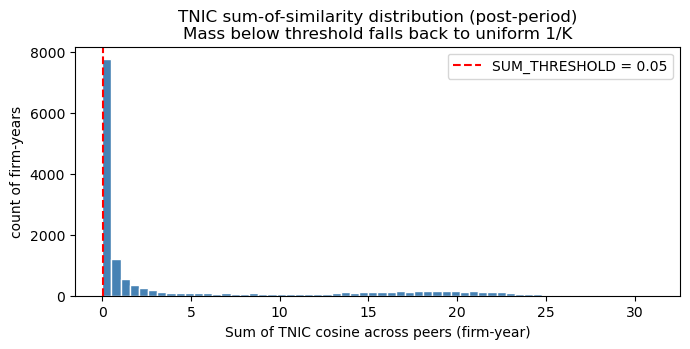

firm-years below gate (uniform 1/K fallback): 2,586/14,592


In [12]:
# Sum-of-similarity diagnostic: histogram across firm-years in post-period.
post_simsum = (
    tnic_share_panel[tnic_share_panel["year"].isin(POST_YEARS)]
    .groupby(["gvkey", "year"], as_index=False)
    .agg(sim_sum=("sim_sum", "first"))
)
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.hist(post_simsum["sim_sum"].clip(upper=50), bins=60, color="steelblue", edgecolor="white")
ax.axvline(SUM_THRESHOLD, color="red", linestyle="--",
           label=f"SUM_THRESHOLD = {SUM_THRESHOLD}")
ax.set_xlabel("Sum of TNIC cosine across peers (firm-year)")
ax.set_ylabel("count of firm-years")
ax.set_title("TNIC sum-of-similarity distribution (post-period)\n"
             "Mass below threshold falls back to uniform 1/K")
ax.legend()
plt.tight_layout()
fig.savefig(OUT_FIGS / "tnic_simsum_hist.png", dpi=150)
plt.show()

below_gate = (post_simsum["sim_sum"] < SUM_THRESHOLD).sum()
print(f"firm-years below gate (uniform 1/K fallback): {below_gate:,}/{len(post_simsum):,}")


## 5. Pre-COVID prior + TNIC mass → year-specific Dirichlet $\alpha$

The pre-COVID prior is the sales-weighted-count mass aggregated over
2017–2021, at the (firm, segment, NAICS-3) resolution (identical to
`05_wrds_analysis.ipynb`). The TNIC mass is layered on top, at the same
resolution but using the firm-level peer-weighted industry shares
broadcast across all segments of the firm:

$$
\alpha_{f,s,k,y} \;=\; m^{\text{preCOVID}}_{f,s,k}
\;+\; c_{\text{tnic}}\,M_{f,s}\,\text{tnic\_share}_{f,y,k}
\;+\; \varepsilon.
$$

Here $M_{f,s}=\sum_k m^{\text{preCOVID}}_{f,s,k}$ is the segment's total
pre-COVID mass so the TNIC term is on a comparable scale.

For segments with zero pre-COVID mass (firms that appear only post-2021),
$M_{f,s}$ is replaced by the segment's first-observed-year sales as a
proxy so the TNIC channel still contributes informative mass.


In [13]:
# Pre-COVID sales-weighted-count mass per (firm, segment, naics_code).
pre = (
    panel[panel["year"].isin(PRE_COVID_YEARS)]
    .groupby(
        ["gvkey", "conm", "firm_segment_name", "naics_code"],
        as_index=False,
    )
    .agg(prior_mass=("sales_weighted_count", "sum"))
)
pre["prior_mass"] = pre["prior_mass"] + SMOOTH

# Total pre-COVID mass per segment for scaling the TNIC contribution.
seg_pre_total = (
    pre.groupby(["gvkey", "conm", "firm_segment_name"], as_index=False)
    .agg(M_seg=("prior_mass", "sum"))
)
print(f"pre-COVID prior rows (firm × segment × naics_code): {len(pre):,}")
print(f"segments with pre-COVID mass: {len(seg_pre_total):,}")


pre-COVID prior rows (firm × segment × naics_code): 5,215
segments with pre-COVID mass: 2,748


In [14]:
# For segments with no pre-COVID mass (firms / segments that first appeared
# in or after 2022), use the first observed evidence-year sales as a proxy
# for the scaling M_seg.
all_segs = panel[["gvkey", "conm", "firm_segment_name"]].drop_duplicates()
need_proxy = all_segs.merge(
    seg_pre_total[["gvkey", "firm_segment_name"]], on=["gvkey", "firm_segment_name"],
    how="left", indicator=True,
).query("_merge == 'left_only'")[["gvkey", "conm", "firm_segment_name"]]

if len(need_proxy):
    proxy_sales = (
        panel.merge(need_proxy, on=["gvkey", "conm", "firm_segment_name"])
        .sort_values("year")
        .groupby(["gvkey", "conm", "firm_segment_name"], as_index=False)
        .agg(M_seg=("sales", "first"))
    )
    seg_pre_total = pd.concat([seg_pre_total, proxy_sales], ignore_index=True)
print(f"total segments with M_seg (pre-COVID + proxy): {len(seg_pre_total):,}")


total segments with M_seg (pre-COVID + proxy): 3,184


In [15]:
def build_prior_for_year(target_year: int, c_tnic: float) -> pd.DataFrame:
    # alpha_prior at (gvkey, conm, firm_segment_name, naics_code) for
    # target_year. Combines pre-COVID mass + c_tnic * M_seg * tnic_share.
    # Firms with no informative TNIC signal in target_year get a uniform
    # 1/K TNIC term (same effective floor as the legacy 03_priors notebook).
    # Skeleton: every (firm, segment) by every industry (NAICS-3).
    seg_keys = panel[["gvkey", "conm", "firm_segment_name"]].drop_duplicates()
    skel = seg_keys.assign(_k=1).merge(
        pd.DataFrame({"naics_code": industries, "_k": 1}), on="_k"
    ).drop(columns="_k")

    # Pre-COVID mass.
    skel = skel.merge(pre, on=["gvkey", "conm", "firm_segment_name", "naics_code"], how="left")
    skel["prior_mass"] = skel["prior_mass"].fillna(SMOOTH)

    # M_seg for scaling TNIC.
    skel = skel.merge(seg_pre_total, on=["gvkey", "conm", "firm_segment_name"], how="left")
    skel["M_seg"] = skel["M_seg"].fillna(0.0)

    # TNIC share for target_year.
    ts = tnic_share_panel[tnic_share_panel["year"] == target_year]
    ts_lookup = ts.set_index(["gvkey", "naics_code"])["tnic_share"].to_dict()
    informative_firms = set(
        ts.loc[ts["tnic_informative"], "gvkey"].unique()
    )

    def tnic_for_row(g, k):
        if g in informative_firms:
            return ts_lookup.get((g, k), 0.0) or 0.0
        return 1.0 / K  # uniform fallback

    skel["tnic_share"] = [tnic_for_row(g, k) for g, k in zip(skel["gvkey"], skel["naics_code"])]
    skel["alpha_tnic_mass"] = c_tnic * skel["M_seg"] * skel["tnic_share"]
    skel["alpha"] = skel["prior_mass"] + skel["alpha_tnic_mass"] + SMOOTH
    skel["year"] = target_year
    return skel


# Sanity check: build one year and inspect.
prior_2022 = build_prior_for_year(2022, C_TNIC)
print(f"prior rows for FY2022: {len(prior_2022):,}")
prior_2022.head()


prior rows for FY2022: 296,112


,gvkey,conm,firm_segment_name,naics_code,prior_mass,M_seg,tnic_share,alpha_tnic_mass,alpha,year
0,001019,AFA PROTECTIVE SYSTEMS INC,AFA PROTECTIVE SYSTEMS INC - United States,111,1.000000e-09,6987.093591,0.010753,75.130039,75.130039,2022
1,001019,AFA PROTECTIVE SYSTEMS INC,AFA PROTECTIVE SYSTEMS INC - United States,112,1.000000e-09,6987.093591,0.010753,75.130039,75.130039,2022
2,001019,AFA PROTECTIVE SYSTEMS INC,AFA PROTECTIVE SYSTEMS INC - United States,113,1.000000e-09,6987.093591,0.010753,75.130039,75.130039,2022
3,001019,AFA PROTECTIVE SYSTEMS INC,AFA PROTECTIVE SYSTEMS INC - United States,115,1.000000e-09,6987.093591,0.010753,75.130039,75.130039,2022
4,001019,AFA PROTECTIVE SYSTEMS INC,AFA PROTECTIVE SYSTEMS INC - United States,211,1.000000e-09,6987.093591,0.010753,75.130039,75.130039,2022


## 6. Posterior inference: HHI / CR4 distributions per industry-year

Same conjugate-update structure as `05_wrds_analysis.ipynb`:

$$
\alpha^{\text{post}}_{f,s,k,t} = \alpha^{\text{prior}}_{f,s,k,t} + y_{f,s,k,t}
$$

where the evidence $y$ is the year-$t$ sales-weighted-count. We then draw
$\theta_{f,s} \sim \text{Dirichlet}(\alpha^{\text{post}}_{f,s,\cdot,t})$,
multiply by segment sales to get segment-industry sales for each draw,
aggregate to firm-industry, and finally compute per-draw HHI and CR4 within
each industry-year.

This helper is invoked **twice**: once with `c_tnic=C_TNIC` (our preferred
spec), once with `c_tnic=0` (Bayesian-no-TNIC ablation for the three-way
comparison).


In [16]:
def posterior_year(target_year: int, c_tnic: float, n_draws: int = N_DRAWS):
    # Returns (df_cr4_draws, df_hhi_draws, df_firm_industry_draws) for one target year.
    prior_df = build_prior_for_year(target_year, c_tnic)

    # Year-specific evidence mass.
    ev = (
        panel[panel["year"] == target_year]
        .groupby(
            ["gvkey", "conm", "firm_segment_name", "naics_code"],
            as_index=False,
        )
        .agg(evidence_mass=("sales_weighted_count", "sum"),
             segment_sales=("sales", "max"))
    )

    df_post = prior_df.merge(
        ev,
        on=["gvkey", "conm", "firm_segment_name", "naics_code"],
        how="left",
    )
    df_post["evidence_mass"] = df_post["evidence_mass"].fillna(0.0)
    df_post["alpha_post"] = df_post["alpha"] + df_post["evidence_mass"]

    # Segment sales = max over industries (constant within segment-year);
    # drop segments with zero sales in target year.
    seg_sales = (
        panel[panel["year"] == target_year]
        .groupby(["gvkey", "firm_segment_name"], as_index=False)
        .agg(seg_sales=("sales", "max"))
    )
    df_post = df_post.merge(seg_sales, on=["gvkey", "firm_segment_name"], how="inner")
    df_post = df_post[df_post["seg_sales"] > 0]

    # Posterior draws per segment.
    results = []
    seg_keys = ["gvkey", "conm", "firm_segment_name"]
    for keys, grp in df_post.groupby(seg_keys, sort=False):
        alpha = grp["alpha_post"].to_numpy(dtype=float)
        if not np.all(np.isfinite(alpha)) or np.any(alpha <= 0):
            continue
        sales = float(grp["seg_sales"].iloc[0])
        theta = rng.dirichlet(alpha, size=n_draws)  # (n_draws, K_seg)
        for j, ind in enumerate(grp["naics_code"].tolist()):
            results.append(pd.DataFrame({
                "draw": np.arange(n_draws),
                "year": target_year,
                "naics_code": ind,
                "gvkey": keys[0],
                "conm": keys[1],
                "firm_segment_name": keys[2],
                "seg_ind_sales": sales * theta[:, j],
            }))
    draws = pd.concat(results, ignore_index=True)

    df_firm_ind = (
        draws.groupby(["draw", "year", "naics_code", "gvkey", "conm"], as_index=False)
        .agg(industry_sales=("seg_ind_sales", "sum"))
    )
    df_firm_ind["industry_total_sales"] = df_firm_ind.groupby(
        ["draw", "year", "naics_code"]
    )["industry_sales"].transform("sum")
    df_firm_ind["market_share"] = (
        df_firm_ind["industry_sales"] / df_firm_ind["industry_total_sales"]
    )
    df_firm_ind = df_firm_ind.sort_values(
        ["draw", "year", "naics_code", "market_share"],
        ascending=[True, True, True, False],
    )
    df_firm_ind["rank"] = df_firm_ind.groupby(
        ["draw", "year", "naics_code"]
    ).cumcount() + 1

    df_cr4 = (
        df_firm_ind[df_firm_ind["rank"] <= 4]
        .groupby(["draw", "year", "naics_code"], as_index=False)
        .agg(cr4=("market_share", "sum"))
    )
    df_hhi = (
        df_firm_ind.groupby(["draw", "year", "naics_code"], as_index=False)
        .agg(hhi=("market_share", lambda x: (x ** 2).sum() * 10000.0))
    )
    return df_cr4, df_hhi, df_firm_ind


In [ ]:
# Run posterior with TNIC (preferred spec) and without (ablation).
def run_all_years(c_tnic: float):
    out_cr4, out_hhi = [], []
    for y in POST_YEARS:
        df_cr4_y, df_hhi_y, _ = posterior_year(y, c_tnic=c_tnic, n_draws=N_DRAWS)
        out_cr4.append(df_cr4_y)
        out_hhi.append(df_hhi_y)
    return pd.concat(out_cr4, ignore_index=True), pd.concat(out_hhi, ignore_index=True)


C_TNIC = 0.5
print(f"Running posterior with c_tnic = {C_TNIC} (preferred spec)...")
cr4_tnic, hhi_tnic = run_all_years(C_TNIC)
print(f"  CR4 draws: {len(cr4_tnic):,}, HHI draws: {len(hhi_tnic):,}")


Running posterior with c_tnic = 0.5 (preferred spec)...


In [ ]:
# print(f"Running posterior with c_tnic = 0 (Bayesian-no-TNIC ablation)...")
# cr4_no_tnic, hhi_no_tnic = run_all_years(0.0)
# print(f"  CR4 draws: {len(cr4_no_tnic):,}, HHI draws: {len(hhi_no_tnic):,}")

## 7. Industry × year summary table (3-way comparison)

Posterior mean and 10/90 quantile band for HHI and CR4 under both specs,
plus the deterministic benchmark.


In [ ]:
def summarise(df_draws, value_col, label):
    return (
        df_draws.groupby(["year", "naics_code"], as_index=False)
        .agg(
            **{
                f"{label}_mean": (value_col, "mean"),
                f"{label}_p10":  (value_col, lambda x: np.percentile(x, 10)),
                f"{label}_p50":  (value_col, lambda x: np.percentile(x, 50)),
                f"{label}_p90":  (value_col, lambda x: np.percentile(x, 90)),
            }
        )
    )


hhi_tnic_sum    = summarise(hhi_tnic, "hhi", "hhi_tnic")
hhi_no_tnic_sum = summarise(hhi_no_tnic, "hhi", "hhi_no_tnic")
cr4_tnic_sum    = summarise(cr4_tnic, "cr4", "cr4_tnic")
cr4_no_tnic_sum = summarise(cr4_no_tnic, "cr4", "cr4_no_tnic")

industry_year_summary = (
    benchmark_hhi
    .merge(hhi_tnic_sum,    on=["year", "naics_code"], how="outer")
    .merge(hhi_no_tnic_sum, on=["year", "naics_code"], how="outer")
    .merge(benchmark_cr4,   on=["year", "naics_code"], how="outer")
    .merge(cr4_tnic_sum,    on=["year", "naics_code"], how="outer")
    .merge(cr4_no_tnic_sum, on=["year", "naics_code"], how="outer")
    .sort_values(["year", "naics_code"])
)
print(f"industry-year summary rows: {len(industry_year_summary):,}")
industry_year_summary.head(10)


industry-year summary rows: 836


,year,naics_code,hhi_benchmark,hhi_tnic_mean,hhi_tnic_p10,hhi_tnic_p50,hhi_tnic_p90,hhi_no_tnic_mean,hhi_no_tnic_p10,hhi_no_tnic_p50,hhi_no_tnic_p90,cr4_benchmark,cr4_tnic_mean,cr4_tnic_p10,cr4_tnic_p50,cr4_tnic_p90,cr4_no_tnic_mean,cr4_no_tnic_p10,cr4_no_tnic_p50,cr4_no_tnic_p90
0,2017,111,5485.306296,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2017,112,10000.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2017,113,5671.757160,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2017,115,10000.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2017,211,640.927828,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.425252,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2017,212,1134.190181,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.535658,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2017,213,963.776661,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.552693,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2017,221,283.268877,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.224822,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2017,236,1162.162021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.593593,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2017,237,1660.526310,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.718460,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 8. Selected-industry HHI/CR4 posterior plots (paper-style)

Posterior densities for a few representative NAICS-3 industries for the
most recent fully-covered year, with the deterministic benchmark line and
both Bayesian specs (with-TNIC and no-TNIC) overlaid.


In [ ]:
TARGET_YEAR = 2025
# Pick industries by total benchmark sales in target year to keep the figure
# informative without hand-curating.
ind_sales = (
    bench_firm_ind[bench_firm_ind["year"] == TARGET_YEAR]
    .groupby("naics_code")["industry_sales"].sum()
    .sort_values(ascending=False)
)
selected_naics = ind_sales.head(6).index.tolist()
print(f"Top-6 NAICS-3 industries by {TARGET_YEAR} benchmark sales: {selected_naics}")


Top-6 NAICS-3 industries by 2025 benchmark sales: ['455', '524', '221', '424', '522', '621']


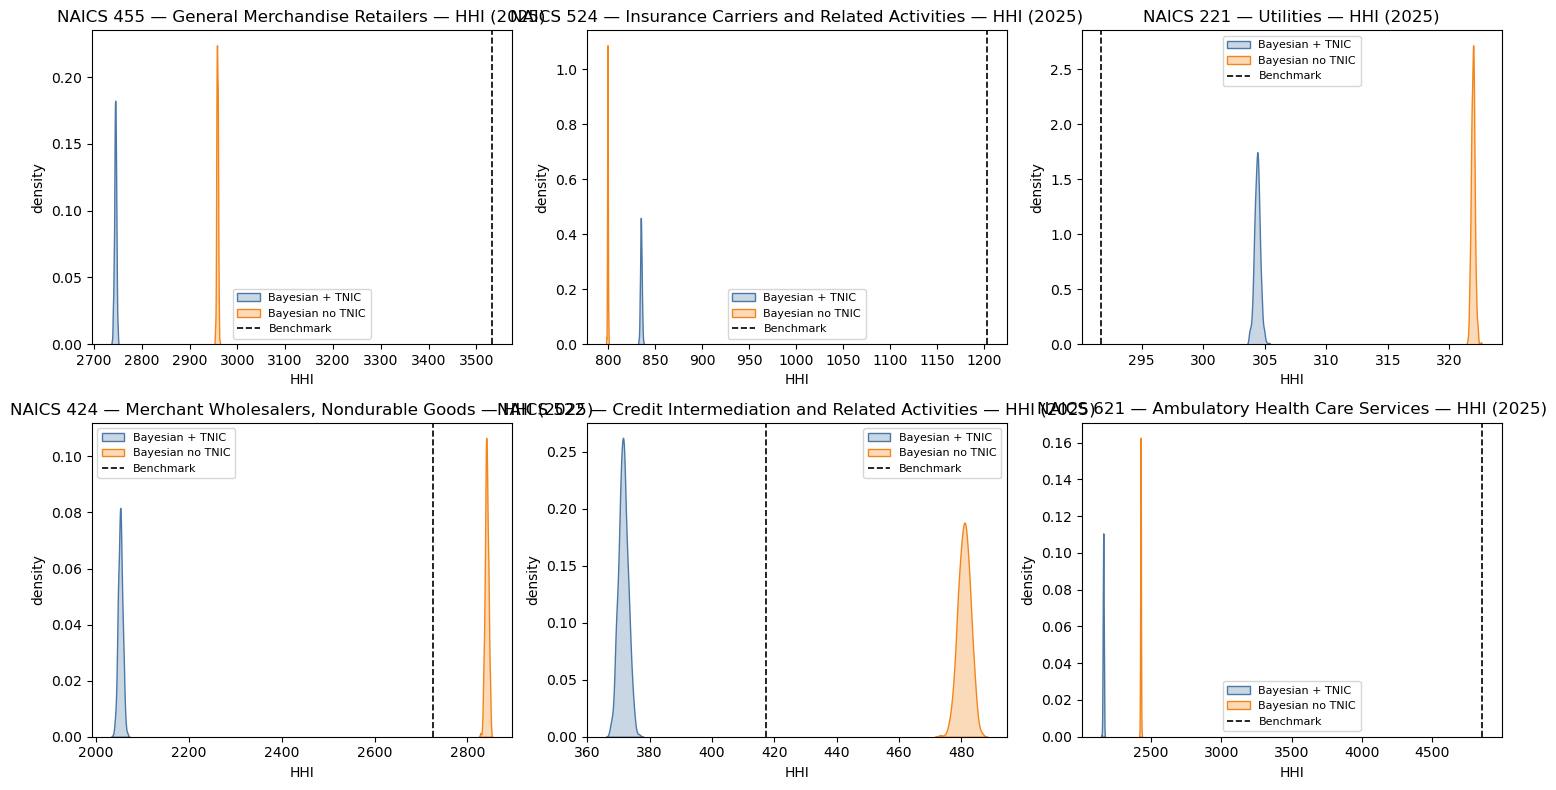

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=False)
for ax, naics in zip(axes.ravel(), selected_naics):
    sub_tnic    = hhi_tnic[(hhi_tnic["year"] == TARGET_YEAR) & (hhi_tnic["naics_code"] == naics)]["hhi"]
    sub_no      = hhi_no_tnic[(hhi_no_tnic["year"] == TARGET_YEAR) & (hhi_no_tnic["naics_code"] == naics)]["hhi"]
    bench_val   = benchmark_hhi[(benchmark_hhi["year"] == TARGET_YEAR) & (benchmark_hhi["naics_code"] == naics)]["hhi_benchmark"]
    if len(sub_tnic):
        sns.kdeplot(sub_tnic, ax=ax, color="#4C78A8", fill=True, alpha=0.3, label="Bayesian + TNIC")
    if len(sub_no):
        sns.kdeplot(sub_no, ax=ax, color="#F58518", fill=True, alpha=0.3, label="Bayesian no TNIC")
    if len(bench_val):
        ax.axvline(bench_val.iloc[0], color="black", linestyle="--", linewidth=1.2, label="Benchmark")
    ax.set_title(f"{naics_plot_label(naics)} — HHI ({TARGET_YEAR})")
    ax.set_xlabel("HHI")
    ax.set_ylabel("density")
    ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(OUT_FIGS / f"hhi_posterior_top6_{TARGET_YEAR}.png", dpi=150)
plt.show()


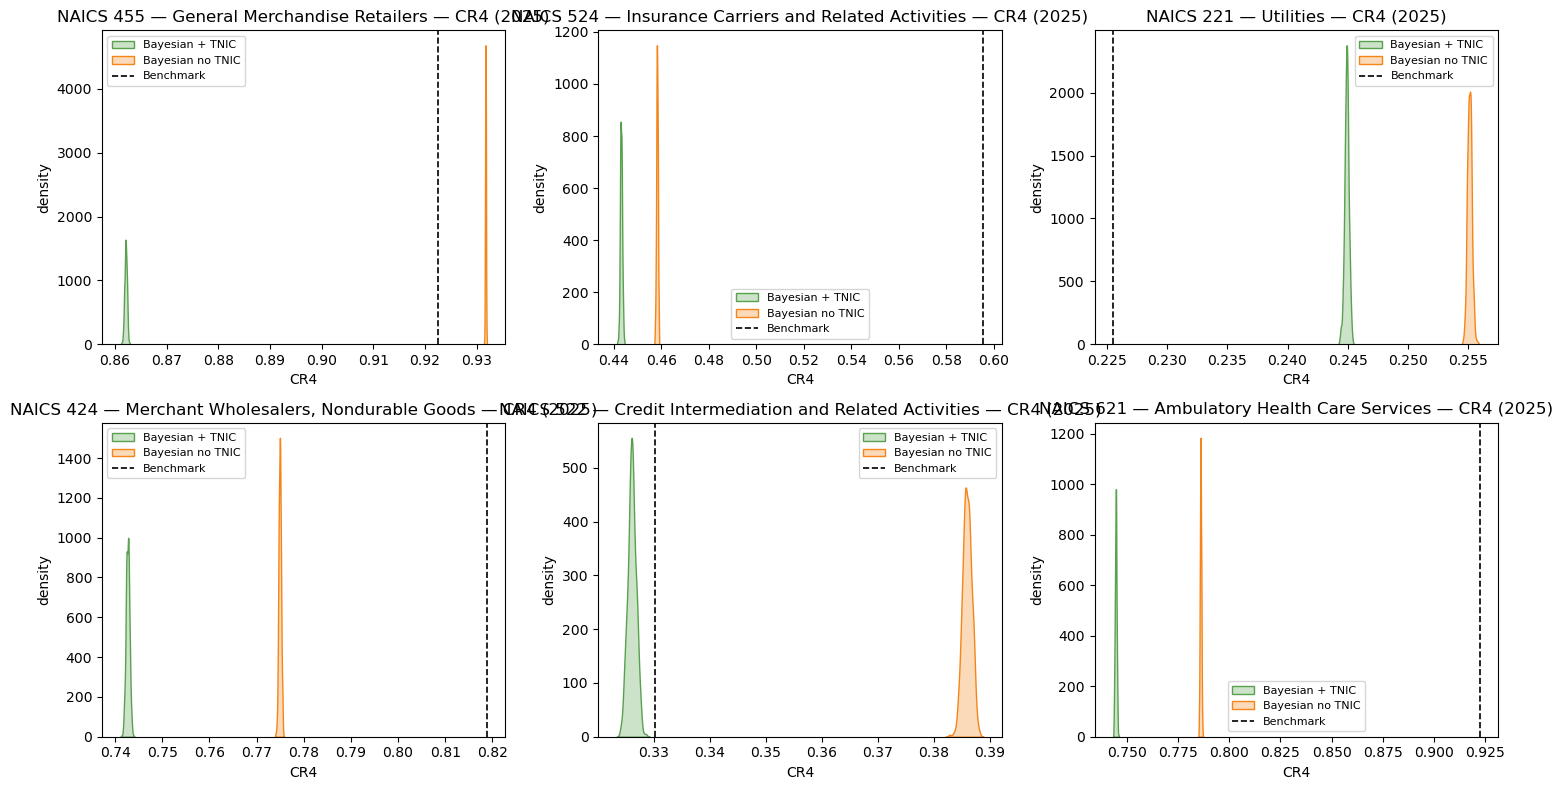

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=False)
for ax, naics in zip(axes.ravel(), selected_naics):
    sub_tnic    = cr4_tnic[(cr4_tnic["year"] == TARGET_YEAR) & (cr4_tnic["naics_code"] == naics)]["cr4"]
    sub_no      = cr4_no_tnic[(cr4_no_tnic["year"] == TARGET_YEAR) & (cr4_no_tnic["naics_code"] == naics)]["cr4"]
    bench_val   = benchmark_cr4[(benchmark_cr4["year"] == TARGET_YEAR) & (benchmark_cr4["naics_code"] == naics)]["cr4_benchmark"]
    if len(sub_tnic):
        sns.kdeplot(sub_tnic, ax=ax, color="#59A14F", fill=True, alpha=0.3, label="Bayesian + TNIC")
    if len(sub_no):
        sns.kdeplot(sub_no, ax=ax, color="#F58518", fill=True, alpha=0.3, label="Bayesian no TNIC")
    if len(bench_val):
        ax.axvline(bench_val.iloc[0], color="black", linestyle="--", linewidth=1.2, label="Benchmark")
    ax.set_title(f"{naics_plot_label(naics)} — CR4 ({TARGET_YEAR})")
    ax.set_xlabel("CR4")
    ax.set_ylabel("density")
    ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(OUT_FIGS / f"cr4_posterior_top6_{TARGET_YEAR}.png", dpi=150)
plt.show()


## 9. Aggregate year-weighted concentration trend

Mirrors §D of `05_wrds_analysis.ipynb`: aggregate to a single annual HHI
and CR4 using year-specific industry sales weights. Three lines: benchmark
deterministic, Bayesian-no-TNIC, Bayesian-with-TNIC. The Bayesian lines
carry their 10–90 posterior band.


In [ ]:
# Year-specific industry sales weights (from benchmark allocation).
year_weights = (
    bench_firm_ind.groupby(["year", "naics_code"], as_index=False)
    .agg(industry_sales=("industry_total_sales", "first"))
)
year_weights["industry_weight_year"] = (
    year_weights["industry_sales"]
    / year_weights.groupby("year")["industry_sales"].transform("sum")
)


def agg_year_weighted(df_draws, value_col):
    j = df_draws.merge(
        year_weights[["year", "naics_code", "industry_weight_year"]],
        on=["year", "naics_code"], how="inner",
    )
    j["weighted"] = j[value_col] * j["industry_weight_year"]
    return (
        j.groupby(["year", "draw"], as_index=False)
        .agg(value=("weighted", "sum"))
    )


agg_hhi_tnic    = agg_year_weighted(hhi_tnic, "hhi")
agg_hhi_no_tnic = agg_year_weighted(hhi_no_tnic, "hhi")
agg_cr4_tnic    = agg_year_weighted(cr4_tnic, "cr4")
agg_cr4_no_tnic = agg_year_weighted(cr4_no_tnic, "cr4")


def aggregate_summary(df, label):
    return (
        df.groupby("year", as_index=False)
        .agg(
            mean=("value", "mean"),
            p10=("value", lambda x: np.percentile(x, 10)),
            p90=("value", lambda x: np.percentile(x, 90)),
        )
        .assign(spec=label)
    )


agg_hhi_combined = pd.concat([
    aggregate_summary(agg_hhi_tnic, "Bayesian + TNIC"),
    aggregate_summary(agg_hhi_no_tnic, "Bayesian no TNIC"),
])
agg_cr4_combined = pd.concat([
    aggregate_summary(agg_cr4_tnic, "Bayesian + TNIC"),
    aggregate_summary(agg_cr4_no_tnic, "Bayesian no TNIC"),
])

# Benchmark aggregate.
bench_hhi_agg = (
    benchmark_hhi.merge(
        year_weights[["year", "naics_code", "industry_weight_year"]],
        on=["year", "naics_code"]
    )
    .assign(weighted=lambda d: d["hhi_benchmark"] * d["industry_weight_year"])
    .groupby("year", as_index=False).agg(value=("weighted", "sum"))
)
bench_cr4_agg = (
    benchmark_cr4.merge(
        year_weights[["year", "naics_code", "industry_weight_year"]],
        on=["year", "naics_code"]
    )
    .assign(weighted=lambda d: d["cr4_benchmark"] * d["industry_weight_year"])
    .groupby("year", as_index=False).agg(value=("weighted", "sum"))
)


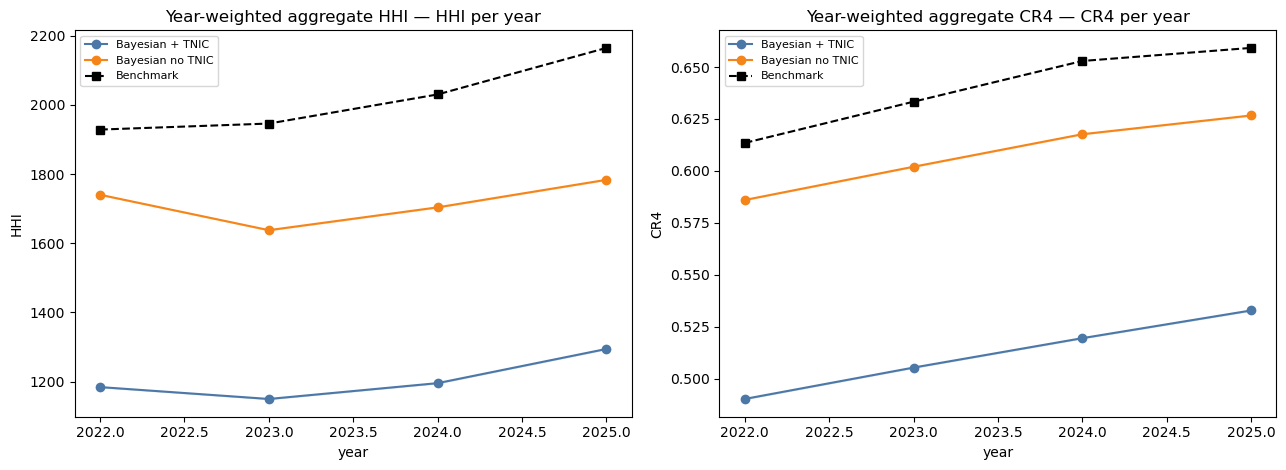

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, agg, bench, ylabel in [
    (axes[0], agg_hhi_combined, bench_hhi_agg, "HHI"),
    (axes[1], agg_cr4_combined, bench_cr4_agg, "CR4"),
]:
    for label, color in [("Bayesian + TNIC", "#4C78A8"),
                         ("Bayesian no TNIC", "#F58518")]:
        sub = agg[agg["spec"] == label].sort_values("year")
        ax.plot(sub["year"], sub["mean"], marker="o", color=color, label=label)
        ax.fill_between(sub["year"], sub["p10"], sub["p90"], color=color, alpha=0.2)
    bsub = bench.sort_values("year")
    bsub = bsub[bsub["year"].isin(agg["year"].unique())]
    ax.plot(bsub["year"], bsub["value"], marker="s", color="black",
            linestyle="--", label="Benchmark")
    ax.set_title(f"Year-weighted aggregate {ylabel} — {ylabel} per year")
    ax.set_xlabel("year")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(OUT_FIGS / "agg_year_weighted_trend.png", dpi=150)
plt.show()


## 10. Sensitivity: $c_{\text{tnic}} \in \{0, 0.5, 1, 2, 5\}$

Posterior mean HHI and CR4 by (year, NAICS-3) for each TNIC weight. Reuses the
already-computed draws for `c_tnic = 0` and `c_tnic = C_TNIC`; other grid
values trigger an additional `run_all_years` pass each. Also reports the
year-sales-weighted aggregate posterior mean (same weights as §9) and small
multiples for the §8 top industries in `TARGET_YEAR`.


In [ ]:
# C_TNIC_GRID = [0.0, 0.5, 1.0, 2.0, 5.0]


# def _posterior_means_by_industry(cr4_df: pd.DataFrame, hhi_df: pd.DataFrame) -> pd.DataFrame:
#     m_cr4 = cr4_df.groupby(["year", "naics_code"], as_index=False)["cr4"].mean()
#     m_hhi = hhi_df.groupby(["year", "naics_code"], as_index=False)["hhi"].mean()
#     return m_cr4.merge(m_hhi, on=["year", "naics_code"]).rename(
#         columns={"cr4": "cr4_mean", "hhi": "hhi_mean"}
#     )


# draws_by_c: dict[float, tuple[pd.DataFrame, pd.DataFrame]] = {}
# for c in C_TNIC_GRID:
#     if c == 0.0:
#         draws_by_c[c] = (cr4_no_tnic, hhi_no_tnic)
#     elif abs(c - float(C_TNIC)) < 1e-12:
#         draws_by_c[c] = (cr4_tnic, hhi_tnic)
#     else:
#         print(f"Sensitivity: running all post-years for c_tnic = {c} ...")
#         draws_by_c[c] = run_all_years(float(c))

# sens_parts = []
# for c, (c_cr4, c_hhi) in draws_by_c.items():
#     sens_parts.append(_posterior_means_by_industry(c_cr4, c_hhi).assign(c_tnic=c))
# sens_posterior_means = pd.concat(sens_parts, ignore_index=True)
# sens_posterior_means.to_csv(PROCESSED / "priors_c_tnic_sensitivity_means.csv", index=False)
# print(f"saved {PROCESSED / 'priors_c_tnic_sensitivity_means.csv'} ({len(sens_posterior_means):,} rows)")

# # Year-weighted aggregate: mean over posterior draws of weighted HHI/CR4.
# agg_sens_rows = []
# for c, (c_cr4, c_hhi) in sorted(draws_by_c.items()):
#     ah = agg_year_weighted(c_hhi, "hhi")
#     ar = agg_year_weighted(c_cr4, "cr4")
#     hmean = ah.groupby("year", as_index=False)["value"].mean().rename(columns={"value": "hhi_agg_mean"})
#     rmean = ar.groupby("year", as_index=False)["value"].mean().rename(columns={"value": "cr4_agg_mean"})
#     agg_sens_rows.append(hmean.merge(rmean, on="year").assign(c_tnic=c))
# sens_aggregate_by_c = pd.concat(agg_sens_rows, ignore_index=True)
# sens_aggregate_by_c.to_csv(PROCESSED / "priors_c_tnic_sensitivity_aggregate.csv", index=False)
# print(f"saved {PROCESSED / 'priors_c_tnic_sensitivity_aggregate.csv'}")

# fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharex=True)
# for c in sorted(draws_by_c.keys()):
#     sub = sens_aggregate_by_c[sens_aggregate_by_c["c_tnic"] == c].sort_values("year")
#     axes[0].plot(sub["year"], sub["hhi_agg_mean"], marker="o", label=f"c={c:g}")
#     axes[1].plot(sub["year"], sub["cr4_agg_mean"], marker="o", label=f"c={c:g}")
# axes[0].set_title("Year-weighted aggregate — posterior mean HHI")
# axes[1].set_title("Year-weighted aggregate — posterior mean CR4")
# for ax in axes:
#     ax.set_xlabel("year")
#     ax.legend(fontsize=7, ncol=2)
# plt.tight_layout()
# fig.savefig(OUT_FIGS / "c_tnic_sensitivity_aggregate.png", dpi=150)
# plt.show()

# fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
# for ax, naics in zip(axes.ravel(), selected_naics):
#     d = sens_posterior_means[
#         (sens_posterior_means["year"] == TARGET_YEAR)
#         & (sens_posterior_means["naics_code"] == naics)
#     ].sort_values("c_tnic")
#     ax.plot(d["c_tnic"], d["hhi_mean"], marker="o", color="#4C78A8")
#     ax.set_title(naics_plot_label(naics))
#     ax.set_xlabel(r"$c_{\mathrm{tnic}}$")
#     ax.set_ylabel("posterior mean HHI")
# plt.suptitle(f"HHI vs TNIC weight — {TARGET_YEAR} (top industries by sales)", y=1.02)
# plt.tight_layout()
# fig.savefig(OUT_FIGS / f"c_tnic_sensitivity_hhi_by_industry_{TARGET_YEAR}.png", dpi=150)
# plt.show()

# fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
# for ax, naics in zip(axes.ravel(), selected_naics):
#     d = sens_posterior_means[
#         (sens_posterior_means["year"] == TARGET_YEAR)
#         & (sens_posterior_means["naics_code"] == naics)
#     ].sort_values("c_tnic")
#     ax.plot(d["c_tnic"], d["cr4_mean"], marker="o", color="#59A14F")
#     ax.set_title(naics_plot_label(naics))
#     ax.set_xlabel(r"$c_{\mathrm{tnic}}$")
#     ax.set_ylabel("posterior mean CR4")
# plt.suptitle(f"CR4 vs TNIC weight — {TARGET_YEAR} (top industries by sales)", y=1.02)
# plt.tight_layout()
# fig.savefig(OUT_FIGS / f"c_tnic_sensitivity_cr4_by_industry_{TARGET_YEAR}.png", dpi=150)
# plt.show()


Sensitivity: running all post-years for c_tnic = 0.5 ...


KeyboardInterrupt: 

The result is extremely sensitive to a hyperparameter for which there is no principled choice. c_tnic = 1 was picked because "TNIC mass is on the same scale as pre-COVID mass", but that's a scaling convention, not a calibration to evidence. Without external validation, any c_tnic in {0.5, 1, 2} could be defended equally, and they give materially different concentration numbers. This is the failure mode I flagged earlier: "Posterior swings wildly across the grid → TNIC is a strong signal but you have no principled way to pick c_tnic."

The shape of the c_tnic response is inconsistent across industries:
- NAICS 424 (Wholesalers), 522 (Credit), 621 (Healthcare): monotonically declining — more TNIC → less concentration.
- NAICS 524 (Insurance), 221 (Utilities): U-shaped or rising — more TNIC → more concentration after a dip.
- NAICS 455 (General Merchandise): mostly declining but with a curl at the high end.

Implication: TNIC isn't doing one thing — it's doing different things in different industries. In some, peer-smoothing dilutes leading-firm shares (pulling concentration down). In others, peer-smoothing actually pools mass into the leading firms' industries (pulling concentration up). The fact that 524 and 221 rise with c_tnic is particularly worth dwelling on: in those industries, TNIC peers apparently suggest the leading firms are more concentrated in those NAICS codes than NAICS-link counts alone would imply.

This means the TNIC channel isn't a uniform "smoother" — it's substantively reshaping who competes where, in industry-specific ways. Which could be a feature (TNIC is correcting NAICS misclassification) or a bug (TNIC peer-similarity is contaminating allocations across industries that text-share boilerplate without actually competing).

## 11. Save outputs

Three CSVs:
1. `data/external/priors_all_firms.csv` — alpha components per
   (gvkey, firm_segment_name, year, naics_code) for the preferred spec.
2. `data/processed/posterior_cr4_distribution.csv` and
   `posterior_hhi_distribution.csv` — full posterior draws (target spec
   only — ablation is regenerable from the notebook).
3. `data/processed/posterior_summary_industry.csv` — industry-year summary
   with benchmark and both Bayesian specs.

§10 additionally writes `priors_c_tnic_sensitivity_means.csv` and
`priors_c_tnic_sensitivity_aggregate.csv` under `data/processed/`.


In [ ]:
# 1. Priors (preferred spec only; build per post-year).
priors_out = []
for y in POST_YEARS:
    p = build_prior_for_year(y, C_TNIC).copy()
    p["c_tnic"] = C_TNIC
    p["pre_covid_years"] = ",".join(str(x) for x in PRE_COVID_YEARS)
    priors_out.append(p[[
        "gvkey", "conm", "firm_segment_name", "year", "naics_code",
        "prior_mass", "M_seg", "tnic_share", "alpha_tnic_mass", "alpha",
        "c_tnic", "pre_covid_years",
    ]])
priors_df = pd.concat(priors_out, ignore_index=True)
priors_df.to_csv(RAW / "priors_all_firms.csv", index=False)
print(f"priors_all_firms.csv → {len(priors_df):,} rows")

# 2. Posterior draws (preferred spec).
cr4_tnic.to_csv(PROCESSED / "posterior_cr4_distribution.csv", index=False)
hhi_tnic.to_csv(PROCESSED / "posterior_hhi_distribution.csv", index=False)
print(f"posterior_cr4_distribution.csv → {len(cr4_tnic):,} rows")
print(f"posterior_hhi_distribution.csv → {len(hhi_tnic):,} rows")

# 3. Industry-year summary (already built).
industry_year_summary.to_csv(PROCESSED / "posterior_summary_industry.csv", index=False)
print(f"posterior_summary_industry.csv → {len(industry_year_summary):,} rows")


priors_all_firms.csv → 1,184,448 rows
posterior_cr4_distribution.csv → 186,000 rows
posterior_hhi_distribution.csv → 186,000 rows
posterior_summary_industry.csv → 836 rows


## 12. Slide-style figures using the TNIC-augmented prior

Reproduces the four key figures from `slides/wrds_slides_submission.tex` (slides 10–13) using posterior draws from the two-channel prior built in this notebook (pre-COVID sales-weighted counts + TNIC peer-smoothing channel, `c_tnic = 1.0`).

Saved under `OUT_FIGS` (`output/figures/priors_all_firms/`) with `_tnic` suffixes so they can be diffed against the WRDS-only versions in `assets/figures/wrds/`.


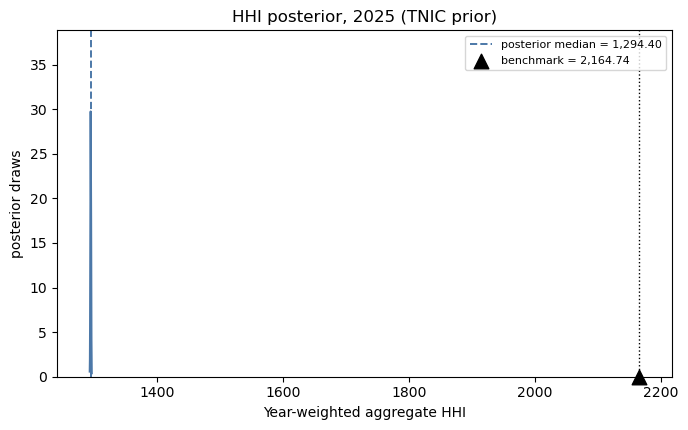

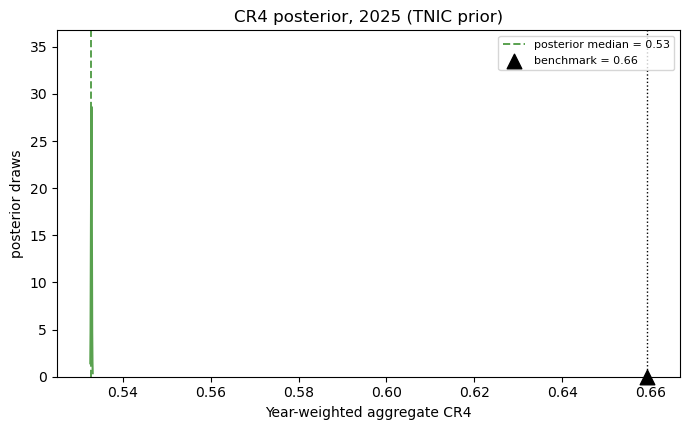

In [ ]:
# === Slide 10 analog ===
# Aggregate year-weighted HHI/CR4 posterior density for TARGET_YEAR, with the
# benchmark point estimate overlaid as a triangle. Uses agg_hhi_tnic /
# agg_cr4_tnic (per-draw aggregates) and bench_hhi_agg / bench_cr4_agg from §9.


def _xlim_from_draws(sub, bench_val, q_lo=1, q_hi=99, pad_frac=0.06):
    """Posterior percentiles + benchmark, with proportional padding."""
    lo = float(min(np.percentile(sub, q_lo), bench_val))
    hi = float(max(np.percentile(sub, q_hi), bench_val))
    pad = pad_frac * (hi - lo) if hi > lo else 0.01 * abs(bench_val)
    return lo - pad, hi + pad


def _plot_aggregate_distribution(agg_draws, bench_agg, label, year, ax, color):
    sub = agg_draws[agg_draws["year"] == year]["value"].values
    bench_val = float(bench_agg.loc[bench_agg["year"] == year, "value"].iloc[0])
    median = float(np.median(sub))

    sns.histplot(sub, bins=40, kde=True, color=color, ax=ax,
                 edgecolor="white", alpha=0.55)
    ax.axvline(median, color=color, linestyle="--", linewidth=1.4,
               label=f"posterior median = {median:,.2f}")
    ax.axvline(bench_val, color="black", linestyle=":", linewidth=1.0)
    ax.scatter([bench_val], [0], marker="^", s=110, color="black",
               zorder=5, clip_on=False, label=f"benchmark = {bench_val:,.2f}")

    xmin, xmax = _xlim_from_draws(sub, bench_val)
    ax.set_xlim(xmin, xmax)

    ax.set_xlabel(f"Year-weighted aggregate {label}")
    ax.set_ylabel("posterior draws")
    ax.set_title(f"{label} posterior, {year} (TNIC prior)")
    ax.legend(fontsize=8, loc="upper right")


fig, ax = plt.subplots(figsize=(7, 4.4))
_plot_aggregate_distribution(agg_hhi_tnic, bench_hhi_agg, "HHI", TARGET_YEAR, ax, "#4C78A8")
plt.tight_layout()
fig.savefig(OUT_FIGS / f"hhi_distribution_{TARGET_YEAR}_tnic.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.4))
_plot_aggregate_distribution(agg_cr4_tnic, bench_cr4_agg, "CR4", TARGET_YEAR, ax, "#59A14F")
plt.tight_layout()
fig.savefig(OUT_FIGS / f"cr4_distribution_{TARGET_YEAR}_tnic.png", dpi=150)
plt.show()

### Slide 11 analog: benchmark vs Bayesian posterior mean, by industry

For each NAICS-3 industry in `TARGET_YEAR`, plot benchmark (x-axis) against the Bayesian posterior mean (y-axis). Points below the 45° line: benchmark overstates concentration.


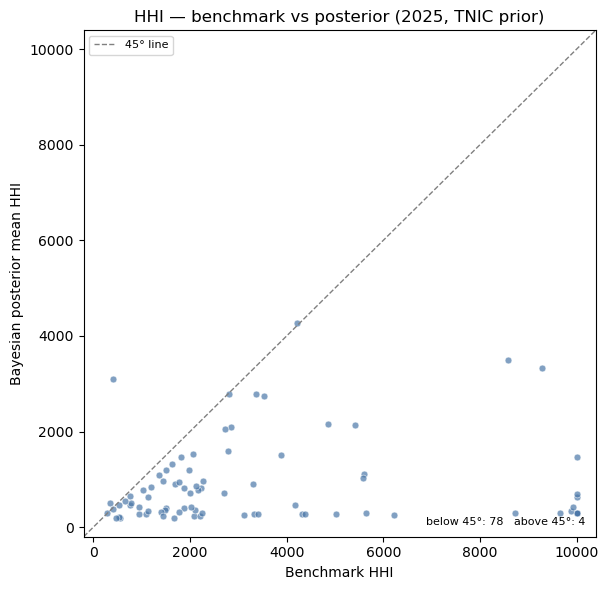

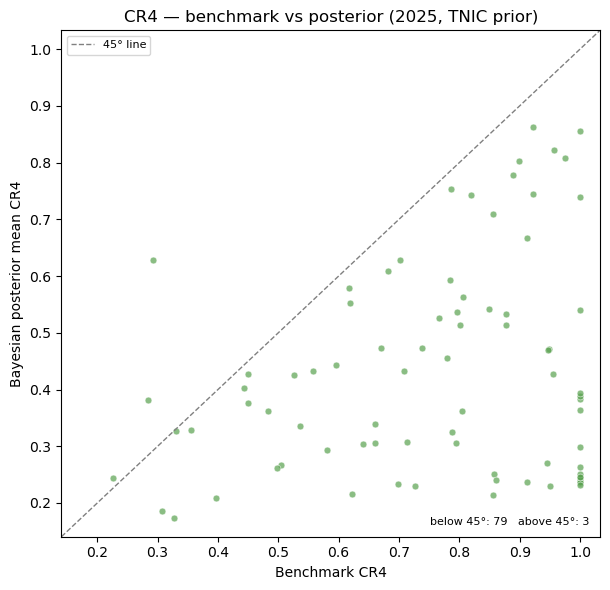

In [ ]:
# === Slide 11 analog ===
# Scatter: benchmark vs Bayesian posterior mean per NAICS-3 industry in
# TARGET_YEAR. Uses industry_year_summary built in §7.


def _scatter_bench_vs_posterior(summary_df, year, bench_col, post_col, label, ax, color):
    d = summary_df[summary_df["year"] == year].dropna(subset=[bench_col, post_col])
    lo = float(min(d[bench_col].min(), d[post_col].min()))
    hi = float(max(d[bench_col].max(), d[post_col].max()))
    pad = 0.04 * (hi - lo)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad],
            color="grey", linestyle="--", linewidth=1, label="45° line")
    ax.scatter(d[bench_col], d[post_col], s=24, alpha=0.7,
               color=color, edgecolor="white", linewidth=0.5)
    ax.set_xlim(lo - pad, hi + pad)
    ax.set_ylim(lo - pad, hi + pad)
    ax.set_xlabel(f"Benchmark {label}")
    ax.set_ylabel(f"Bayesian posterior mean {label}")
    ax.set_title(f"{label} — benchmark vs posterior ({year}, TNIC prior)")
    ax.legend(fontsize=8, loc="upper left")
    below = int((d[post_col] < d[bench_col]).sum())
    above = int((d[post_col] > d[bench_col]).sum())
    ax.text(0.98, 0.02, f"below 45°: {below}   above 45°: {above}",
            transform=ax.transAxes, ha="right", va="bottom", fontsize=8)


fig, ax = plt.subplots(figsize=(6.2, 6))
_scatter_bench_vs_posterior(industry_year_summary, TARGET_YEAR,
                            "hhi_benchmark", "hhi_tnic_mean", "HHI", ax, "#4C78A8")
plt.tight_layout()
fig.savefig(OUT_FIGS / f"hhi_scatter_comparison_{TARGET_YEAR}_tnic.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(6.2, 6))
_scatter_bench_vs_posterior(industry_year_summary, TARGET_YEAR,
                            "cr4_benchmark", "cr4_tnic_mean", "CR4", ax, "#59A14F")
plt.tight_layout()
fig.savefig(OUT_FIGS / f"cr4_scatter_comparison_{TARGET_YEAR}_tnic.png", dpi=150)
plt.show()


### Slide 12 analog: cross-industry heterogeneity in posterior uncertainty

For the top-N NAICS-3 industries by benchmark sales in `TARGET_YEAR`, show the posterior HHI median + 10–90% credible interval as a forest plot, with the benchmark overlaid. Width of the band = within-industry posterior uncertainty.


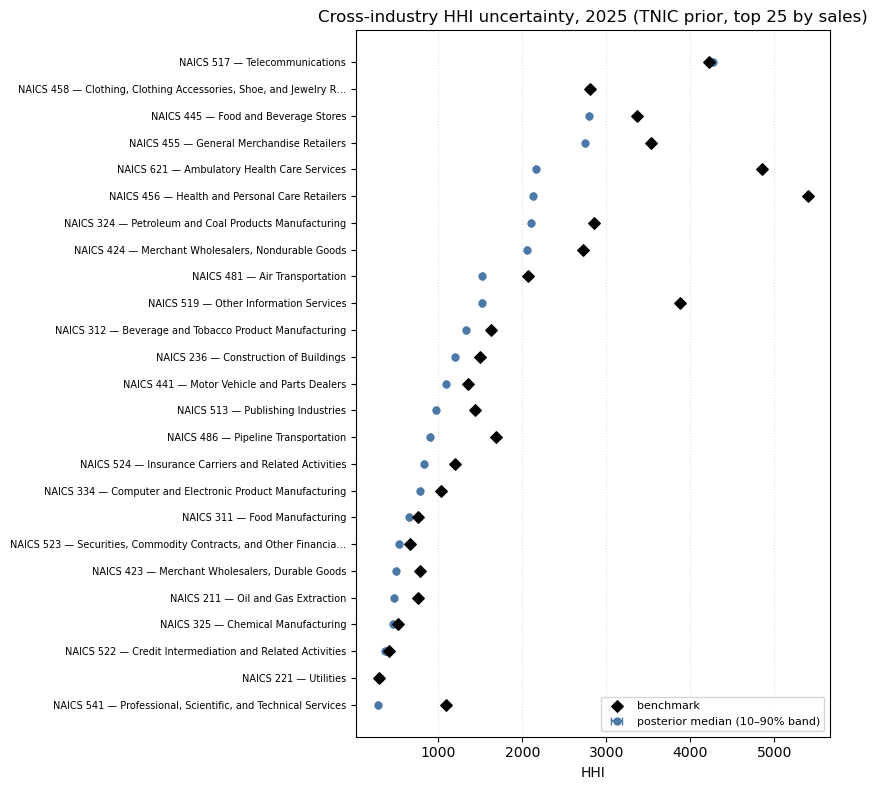

In [ ]:
# === Slide 12 analog ===
# Forest plot: posterior HHI median + 10-90 band per NAICS-3 industry in
# TARGET_YEAR, with benchmark as a black diamond. Industries sorted by posterior
# median (ascending) and restricted to top N by benchmark sales for legibility.

N_TOP_INDUSTRIES = 25

ind_sales_target = (
    bench_firm_ind[bench_firm_ind["year"] == TARGET_YEAR]
    .groupby("naics_code")["industry_sales"].sum()
    .sort_values(ascending=False)
)
top_naics = ind_sales_target.head(N_TOP_INDUSTRIES).index.tolist()

forest = (
    industry_year_summary[
        (industry_year_summary["year"] == TARGET_YEAR)
        & (industry_year_summary["naics_code"].isin(top_naics))
    ]
    .dropna(subset=["hhi_tnic_p50"])
    .sort_values("hhi_tnic_p50", ascending=True)
    .copy()
)
forest["label"] = forest["naics_code"].map(naics_plot_label)
forest["band_lo"] = forest["hhi_tnic_p50"] - forest["hhi_tnic_p10"]
forest["band_hi"] = forest["hhi_tnic_p90"] - forest["hhi_tnic_p50"]

fig, ax = plt.subplots(figsize=(8.5, max(4.5, 0.32 * len(forest))))
y_pos = np.arange(len(forest))
ax.errorbar(forest["hhi_tnic_p50"], y_pos,
            xerr=[forest["band_lo"], forest["band_hi"]],
            fmt="o", color="#4C78A8", ecolor="#4C78A8", elinewidth=1.6,
            capsize=3, markersize=5, label="posterior median (10–90% band)")
ax.scatter(forest["hhi_benchmark"], y_pos, marker="D", s=34,
           color="black", zorder=5, label="benchmark")
ax.set_yticks(y_pos)
ax.set_yticklabels(forest["label"], fontsize=7)
ax.set_xlabel("HHI")
ax.set_title(f"Cross-industry HHI uncertainty, {TARGET_YEAR} "
             f"(TNIC prior, top {N_TOP_INDUSTRIES} by sales)")
ax.legend(fontsize=8, loc="lower right")
ax.grid(axis="x", linestyle=":", alpha=0.4)
plt.tight_layout()
fig.savefig(OUT_FIGS / f"hhi_comparison_by_industry_{TARGET_YEAR}_tnic.png", dpi=150)
plt.show()


### Slide 13 analog: concentration growth (log-change from 2022)

Aggregate year-weighted HHI/CR4 relative to 2022, in log points, computed per posterior draw → mean + 10–90% band. Benchmark shown as a dashed black line. If the lower band lies above zero in 2023–2025, growth is statistically meaningful given allocation uncertainty.


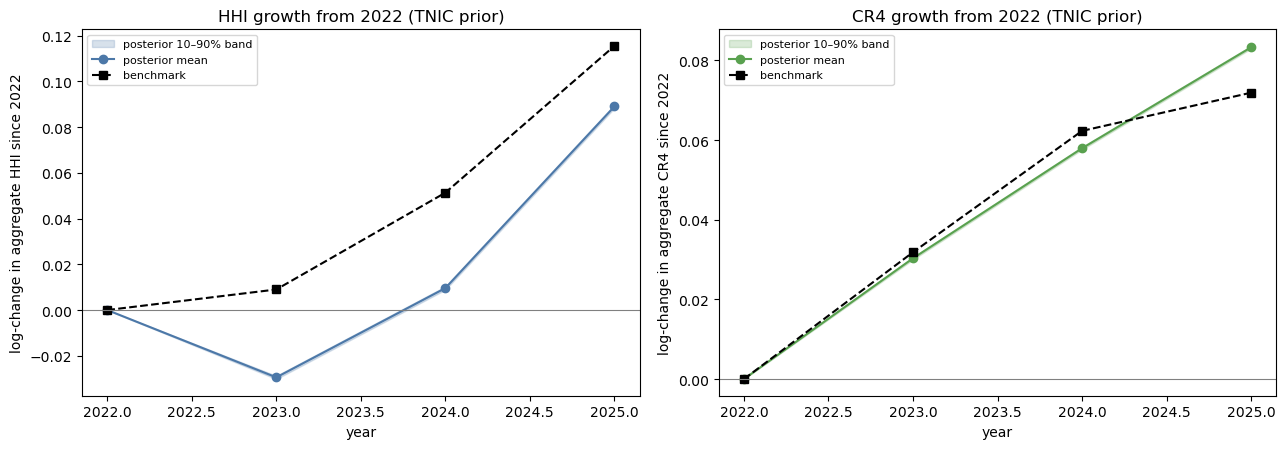

In [ ]:
# === Slide 13 analog ===
# Log-change concentration growth from BASE_YEAR baseline, computed per
# posterior draw → mean + 10–90 band per year. Benchmark shown as dashed line.

BASE_YEAR = 2022


def _log_change_summary(per_draw_df, base_year):
    base = (per_draw_df[per_draw_df["year"] == base_year]
            .set_index("draw")["value"])
    j = per_draw_df.merge(base.rename("base"), left_on="draw", right_index=True)
    j["dlog"] = np.log(j["value"]) - np.log(j["base"])
    return (
        j.groupby("year", as_index=False)
        .agg(
            mean=("dlog", "mean"),
            p10=("dlog", lambda x: np.percentile(x, 10)),
            p90=("dlog", lambda x: np.percentile(x, 90)),
        )
        .sort_values("year")
    )


def _bench_log_change(bench_agg, base_year):
    base = float(bench_agg.loc[bench_agg["year"] == base_year, "value"].iloc[0])
    out = bench_agg.copy()
    out["dlog"] = np.log(out["value"]) - np.log(base)
    return out.sort_values("year")


hhi_dlog = _log_change_summary(agg_hhi_tnic, BASE_YEAR)
cr4_dlog = _log_change_summary(agg_cr4_tnic, BASE_YEAR)
bench_hhi_dlog = _bench_log_change(bench_hhi_agg, BASE_YEAR)
bench_cr4_dlog = _bench_log_change(bench_cr4_agg, BASE_YEAR)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, post, bench, label, color in [
    (axes[0], hhi_dlog, bench_hhi_dlog, "HHI", "#4C78A8"),
    (axes[1], cr4_dlog, bench_cr4_dlog, "CR4", "#59A14F"),
]:
    ax.fill_between(post["year"], post["p10"], post["p90"],
                    color=color, alpha=0.22, label="posterior 10–90% band")
    ax.plot(post["year"], post["mean"], marker="o", color=color,
            label="posterior mean")
    bsub = bench[bench["year"].isin(post["year"].unique())]
    ax.plot(bsub["year"], bsub["dlog"], marker="s", color="black",
            linestyle="--", label="benchmark")
    ax.axhline(0, color="grey", linewidth=0.8)
    ax.set_xlabel("year")
    ax.set_ylabel(f"log-change in aggregate {label} since {BASE_YEAR}")
    ax.set_title(f"{label} growth from {BASE_YEAR} (TNIC prior)")
    ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
fig.savefig(OUT_FIGS / "aggregate_concentration_trends_log_year_weighted_tnic.png", dpi=150)
plt.show()


# Conclusions

NAICS-link counts in Compustat are noisy signals of true allocation. TNIC peer similarity provides an independent signal from 10-K text. Combining them produces a prior that pools information across more sources, which is preferable on Bayesian grounds even absent external validation.

TNIC peer smoothing is best read as shrinkage toward industry patterns of similar firms, which can attenuate concentration in industries where the focal firm is distinctive (e.g. hyperscale cloud) relative to retail-heavy peers.